Start by importing libraries

In [2]:
import pandas as pd
import os
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input

ModuleNotFoundError: No module named 'tensorflow'

# GPU Configuration
Let's check GPU availability and configure TensorFlow to use it efficiently.

In [ ]:
# Check GPU availability
print("TensorFlow version:", tf.__version__)
print("\nGPU Devices:")
print(tf.config.list_physical_devices('GPU'))

# Configure TensorFlow to use GPU memory efficiently
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        # Currently, memory growth needs to be the same across GPUs
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
            
        # If you want to limit GPU memory use to a specific amount, uncomment these lines:
        # tf.config.experimental.set_virtual_device_configuration(
        #     gpus[0],
        #     [tf.config.experimental.VirtualDeviceConfiguration(memory_limit=4096)])
            
        logical_gpus = tf.config.experimental.list_logical_devices('GPU')
        print(f"\nPhysical GPUs: {len(gpus)}, Logical GPUs: {len(logical_gpus)}")
        print("\nGPU memory growth enabled")
    except RuntimeError as e:
        print("\nError configuring GPU:", e)
else:
    print("\nNo GPU found. Running on CPU")
    
# Set mixed precision policy for faster training on modern GPUs
tf.keras.mixed_precision.set_global_policy('mixed_float16')
print("\nMixed precision policy enabled for faster GPU training")

TensorFlow version: 2.18.0

GPU Devices:
[]

No GPU found. Running on CPU

Mixed precision policy enabled for faster GPU training


: 

Getting the dataset path from the dataset folder

In [13]:
# Get the absolute path to the dataset
import os

# Define the project root directory (3 levels up from the notebook location)
current_dir = os.getcwd()  # Get current working directory
project_root = os.path.abspath(os.path.join(current_dir, "../../.."))  # Go up three levels to reach F21DL-Project root

# Construct paths
dataset_path = os.path.join(project_root, "Dataset/Mohamed_Dataset/youtube_dataset.csv")
dataset_path = os.path.normpath(dataset_path)

print("Current directory:", current_dir)
print("Project root:", project_root)
print("Dataset path:", dataset_path)

# Verify the file exists
if os.path.exists(dataset_path):
    print("\nDataset file found!")
else:
    print("\nWARNING: Dataset file not found at:", dataset_path)
    
    # List contents of Dataset directory to help debug
    dataset_dir = os.path.join(project_root, "Dataset")
    if os.path.exists(dataset_dir):
        print("\nContents of Dataset directory:")
        for item in os.listdir(dataset_dir):
            print("-", item)

Current directory: c:\Users\AhmedYasser\Documents\Personal\Heriott_Watt_MSc\F21DL-Machine_Learning\F21DL-Project\Models\CNN\AY_1
Project root: c:\Users\AhmedYasser\Documents\Personal\Heriott_Watt_MSc\F21DL-Machine_Learning\F21DL-Project
Dataset path: c:\Users\AhmedYasser\Documents\Personal\Heriott_Watt_MSc\F21DL-Machine_Learning\F21DL-Project\Dataset\Mohamed_Dataset\youtube_dataset.csv

Dataset file found!


Reading the dataset and printing its size

In [14]:
df = pd.read_csv(dataset_path)
print(f"Dataset size before filtering: {len(df)} rows")
print("\nAvailable columns:")
print(df.columns.tolist())

C:\Users\AhmedYasser\AppData\Local\Temp\ipykernel_52244\3819443545.py:1: DtypeWarning: Columns (14,15,45,46,47,48,52,55,56,57,58,59,60,61,65,66) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(dataset_path)


Dataset size before filtering: 70826 rows

Available columns:
['video_id', 'channel_name', 'category', 'channel_id', 'viewCount', 'likeCount', 'commentCount', 'title', 'description', 'tags', 'publishedAt', 'duration', 'dimension', 'definition', 'caption', 'licensedContent', 'projection', 'liveActualStartTime', 'liveScheduledStartTime', 'concurrentViewers', 'snapshot_date', 'thumbnail_file', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26', 'Unnamed: 27', 'Unnamed: 28', 'Unnamed: 29', 'Unnamed: 30', 'Unnamed: 31', 'Unnamed: 32', 'Unnamed: 33', 'Unnamed: 34', 'Unnamed: 35', 'Unnamed: 36', 'Unnamed: 37', 'Unnamed: 38', 'Unnamed: 39', 'Unnamed: 40', 'Unnamed: 41', 'Unnamed: 42', 'Unnamed: 43', 'Unnamed: 44', 'Unnamed: 45', 'Unnamed: 46', 'Unnamed: 47', 'Unnamed: 48', 'Unnamed: 49', 'Unnamed: 50', 'Unnamed: 51', 'Unnamed: 52', 'Unnamed: 53', 'Unnamed: 54', 'Unnamed: 55', 'Unnamed: 56', 'Unnamed: 57', 'Unnamed: 58', 'Unnamed: 59', 'Unnamed: 60', 'Unnamed: 61', 'Unnam

Filtering out data with invalid thumbnail file name

In [15]:
# Filter out rows with missing thumbnails and target variable
df = df[df["thumbnail_file"].notna() & 
        (df["thumbnail_file"] != "#NAME?") & 
        df["viewCount"].notna()]

print(f"Dataset size after filtering: {len(df)} rows")

Dataset size after filtering: 69753 rows


Doing some data visualization

View count range: 0.0 to 1,022,043,620.0
Log2 view range: 0.00 to 29.93
Normalized view range: 0.00 to 1.00


C:\Users\AhmedYasser\AppData\Local\Temp\ipykernel_52244\777381148.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(['{:.1f}M'.format(x/1_000_000) for x in current_values])


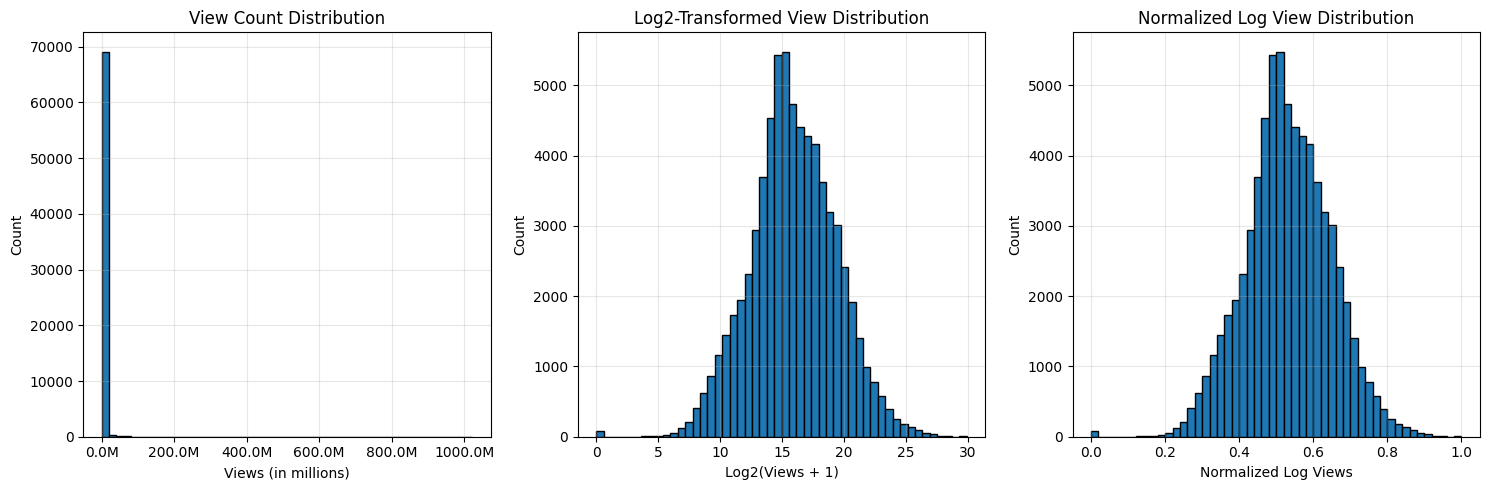

In [16]:
# Log transform the view counts (since view counts are usually highly skewed)
# Using log2 instead of log for better numerical stability
df['log_views'] = np.log2(df['viewCount'] + 1)  # log2 is more numerically stable than natural log
print("View count range:", f"{df['viewCount'].min():,} to {df['viewCount'].max():,}")
print("Log2 view range:", f"{df['log_views'].min():.2f} to {df['log_views'].max():.2f}")

# Normalize log views to [0, 1] range for better training stability
view_min = df['log_views'].min()
view_max = df['log_views'].max()
df['normalized_log_views'] = (df['log_views'] - view_min) / (view_max - view_min)
print("Normalized view range:", f"{df['normalized_log_views'].min():.2f} to {df['normalized_log_views'].max():.2f}")

# Visualize view count distributions
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.hist(df['viewCount'], bins=50, edgecolor='black')
plt.title('View Count Distribution')
plt.xlabel('Views (in millions)')
plt.ylabel('Count')
current_values = plt.gca().get_xticks()
plt.gca().set_xticklabels(['{:.1f}M'.format(x/1_000_000) for x in current_values])
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.hist(df['log_views'], bins=50, edgecolor='black')
plt.title('Log2-Transformed View Distribution')
plt.xlabel('Log2(Views + 1)')
plt.ylabel('Count')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.hist(df['normalized_log_views'], bins=50, edgecolor='black')
plt.title('Normalized Log View Distribution')
plt.xlabel('Normalized Log Views')
plt.ylabel('Count')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Save normalization parameters for later use
normalization_params = {
    'view_min': view_min,
    'view_max': view_max
}

Split the data and view a sample thumbnail


Dataset splits:
Training set size: 48827 rows (70.0%)
Validation set size: 10463 rows (15.0%)
Test set size: 10463 rows (15.0%)


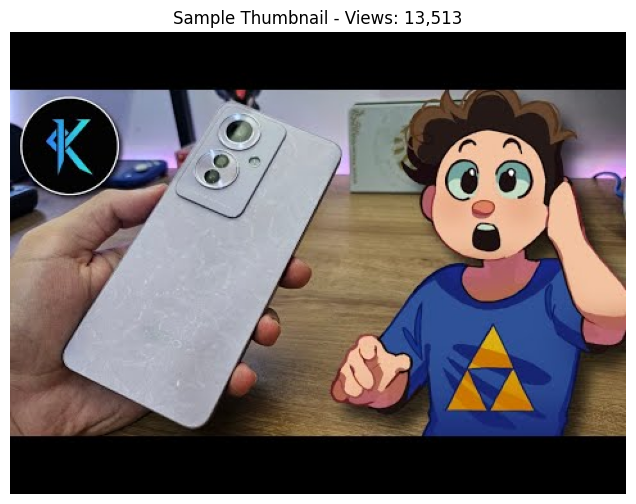

In [17]:
# Split into train (70%), validation (15%), and test (15%)
train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

print("\nDataset splits:")
print(f"Training set size: {len(train_df)} rows ({len(train_df)/len(df)*100:.1f}%)")
print(f"Validation set size: {len(val_df)} rows ({len(val_df)/len(df)*100:.1f}%)")
print(f"Test set size: {len(test_df)} rows ({len(test_df)/len(df)*100:.1f}%)")

# Sample and display a thumbnail
test_idx = 0
test_thumbnail = train_df["thumbnail_file"].iloc[test_idx]
thumbnail_path = os.path.join(current_dir, "../../../Dataset/Mohamed_Dataset/thumbnails", test_thumbnail)
thumbnail_path = os.path.normpath(thumbnail_path)

img = Image.open(thumbnail_path)
plt.figure(figsize=(10, 6))
plt.imshow(img)
plt.axis('off')
plt.title(f"Sample Thumbnail - Views: {train_df['viewCount'].iloc[test_idx]:,.0f}")
plt.show()

# Save dataset splits
splits_dir = os.path.join(current_dir, "data_splits")
os.makedirs(splits_dir, exist_ok=True)
train_df.to_csv(os.path.join(splits_dir, "train.csv"), index=False)
val_df.to_csv(os.path.join(splits_dir, "validation.csv"), index=False)
test_df.to_csv(os.path.join(splits_dir, "test.csv"), index=False)


Setting app data generation

In [8]:
datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,       # <- use this
    rotation_range=15, width_shift_range=0.1,
    height_shift_range=0.1, horizontal_flip=True,
    fill_mode='nearest'
)
val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

# Set up the generators
batch_size = 32
img_size = (224, 224)  # EfficientNetB0 default input size

train_generator = datagen.flow_from_dataframe(
    train_df,
    directory=os.path.join(current_dir, "../../../Dataset/Mohamed_Dataset/thumbnails"),
    x_col="thumbnail_file",
    y_col="normalized_log_views",  # Use normalized values
    target_size=img_size,
    batch_size=batch_size,
    class_mode='raw'
)

validation_generator = val_datagen.flow_from_dataframe(
    val_df,
    directory=os.path.join(current_dir, "../../../Dataset/Mohamed_Dataset/thumbnails"),
    x_col="thumbnail_file",
    y_col="normalized_log_views",  # Use normalized values
    target_size=img_size,
    batch_size=batch_size,
    class_mode='raw'
)

Found 48827 validated image filenames.
Found 10463 validated image filenames.
Found 10463 validated image filenames.


Create and combine model

In [18]:
# Create the model
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the base model
base_model.trainable = False

# Add custom layers with dropout for regularization
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu', kernel_initializer='he_normal')(x)
x = tf.keras.layers.Dropout(0.3)(x)  # Add dropout
x = Dense(128, activation='relu', kernel_initializer='he_normal')(x)
x = tf.keras.layers.Dropout(0.2)(x)  # Add dropout
# Use linear activation for regression instead of sigmoid
predictions = Dense(1, activation='linear')(x)  

model = Model(inputs=base_model.input, outputs=predictions)

# Use an even lower learning rate and gradient clipping
optimizer = tf.keras.optimizers.Adam(
    learning_rate=1e-5,  # Reduced learning rate
    clipnorm=0.5  # More aggressive gradient clipping
)

# Compile the model
model.compile(
    optimizer=optimizer,
    loss='mse',
    metrics=['mae']
)

# Set up callbacks with more patience
checkpoint_path = os.path.join(current_dir, "checkpoints")
os.makedirs(checkpoint_path, exist_ok=True)

callbacks = [
    ModelCheckpoint(
        os.path.join(checkpoint_path, 'model_best.h5'),
        monitor='val_loss',
        save_best_only=True,
        mode='min',
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=10,  # Increased patience
        restore_best_weights=True,
        verbose=1
    ),
    # More gradual learning rate reduction
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,  # More gradual reduction
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
]

Train the model

In [19]:
# Train the model
epochs = 1  # Increased epochs to allow proper convergence
history = model.fit(
    train_generator,
    epochs=epochs,
    validation_data=validation_generator,
    callbacks=callbacks,
    verbose=1
)

# Print interpretation of the metrics
print("\nInterpreting the final metrics:")
print("Since we're using normalized log views (scaled to [0,1]):")
print(f"- Loss (MSE) of {history.history['loss'][-1]:.4f} means the average squared error is {history.history['loss'][-1]*100:.1f}% of the full range")
print(f"- MAE of {history.history['mae'][-1]:.4f} means predictions are off by {history.history['mae'][-1]*100:.1f}% of the full range on average")

# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Time')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Model MAE Over Time')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Calculate approximate error in terms of original view counts
view_range = view_max - view_min  # Range of log views
avg_mae_log = history.history['mae'][-1] * view_range  # Denormalize MAE
print(f"\nIn terms of log2 views:")
print(f"- Average error is approximately ±{avg_mae_log:.2f} in log2 scale")
print(f"- This means predictions could be off by a factor of about {2**avg_mae_log:.1f}x")

# Save the model in SavedModel format
savedmodel_path = os.path.join(checkpoint_path, 'saved_model')
model.save(savedmodel_path, save_format='tf')
print(f"\nModel saved to {savedmodel_path}")

# Also save the training history
history_path = os.path.join(checkpoint_path, 'training_history.npy')
np.save(history_path, history.history)
print(f"Training history saved to {history_path}")

1526/1526 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.2405 - mae: 0.3775

KeyboardInterrupt: 

Understanding the Scale Compression:

Original Views | Log2 Scale | Normalized [0,1]
---------------------------------------------
       1,000 |      9.97 | 0.3330
      10,000 |     13.29 | 0.4440
     100,000 |     16.61 | 0.5550
   1,000,000 |     19.93 | 0.6660


NameError: name 'history' is not defined

Loading best  model

In [20]:
# Load the best saved model
savedmodel_path = os.path.join(checkpoint_path, 'saved_model')
if os.path.exists(savedmodel_path):
    print("\nLoading saved model...")
    best_model = tf.keras.models.load_model(savedmodel_path)
    
    # Load training history if available
    history_path = os.path.join(checkpoint_path, 'training_history.npy')
    if os.path.exists(history_path):
        print("Loading training history...")
        history = np.load(history_path, allow_pickle=True).item()
        
        # Plot training history if available
        plt.figure(figsize=(12, 4))
        
        plt.subplot(1, 2, 1)
        plt.plot(history['loss'], label='Training Loss')
        plt.plot(history['val_loss'], label='Validation Loss')
        plt.title('Model Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        
        plt.subplot(1, 2, 2)
        plt.plot(history['mae'], label='Training MAE')
        plt.plot(history['val_mae'], label='Validation MAE')
        plt.title('Model MAE')
        plt.xlabel('Epoch')
        plt.ylabel('MAE')
        plt.legend()
        
        plt.tight_layout()
        plt.show()
else:
    print("\nNo saved model found at", savedmodel_path)
    best_model = model  # Use the current model if no saved model exists


No saved model found at c:\Users\AhmedYasser\Documents\Personal\Heriott_Watt_MSc\F21DL-Machine_Learning\F21DL-Project\Models\CNN\AY_1\checkpoints\saved_model


Testing model

In [21]:

# Create test data generator
test_generator = val_datagen.flow_from_dataframe(
    test_df,
    directory=os.path.join(current_dir, "../../../Dataset/Mohamed_Dataset/thumbnails"),
    x_col="thumbnail_file",
    y_col="log_views",
    target_size=img_size,
    batch_size=batch_size,
    shuffle=False,  # Important: keep order for analysis
    class_mode='raw'
)

# Evaluate on test set
test_loss, test_mae = best_model.evaluate(test_generator)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test MAE: {test_mae:.4f}")

# Make predictions
predictions = best_model.predict(test_generator)

# Convert log predictions back to actual views
predicted_views = np.expm1(predictions)
actual_views = np.expm1(test_df['log_views'].values)

Found 10463 validated image filenames.
  5/327 ━━━━━━━━━━━━━━━━━━━━ 7:35 1s/step - loss: 255.5145 - mae: 15.5953

KeyboardInterrupt: 

Calculating metrics

In [ ]:

# Calculate additional metrics
mse = np.mean((actual_views - predicted_views.flatten())**2)
rmse = np.sqrt(mse)
mae = np.mean(np.abs(actual_views - predicted_views.flatten()))
r2 = 1 - (np.sum((actual_views - predicted_views.flatten())**2) / 
          np.sum((actual_views - np.mean(actual_views))**2))

print("\nMetrics on original scale (views):")
print(f"MSE: {mse:,.0f}")
print(f"RMSE: {rmse:,.0f}")
print(f"MAE: {mae:,.0f}")
print(f"R² Score: {r2:.4f}")


Visualize predictions

In [ ]:

# Visualize predictions
plt.figure(figsize=(15, 5))

# Scatter plot of predicted vs actual views (log scale)
plt.subplot(1, 3, 1)
plt.scatter(test_df['log_views'], predictions, alpha=0.5)
plt.plot([test_df['log_views'].min(), test_df['log_views'].max()], 
         [test_df['log_views'].min(), test_df['log_views'].max()], 
         'r--', lw=2)
plt.xlabel('Actual Log Views')
plt.ylabel('Predicted Log Views')
plt.title('Predictions vs Actual (Log Scale)')

# Scatter plot of predicted vs actual views
plt.subplot(1, 3, 2)
plt.scatter(actual_views, predicted_views, alpha=0.5)
plt.plot([actual_views.min(), actual_views.max()], 
         [actual_views.min(), actual_views.max()], 
         'r--', lw=2)
plt.xlabel('Actual Views')
plt.ylabel('Predicted Views')
plt.title('Predictions vs Actual')
plt.ticklabel_format(style='plain', axis='both')

# Error distribution
plt.subplot(1, 3, 3)
errors = predicted_views.flatten() - actual_views
plt.hist(errors, bins=50)
plt.xlabel('Prediction Error (views)')
plt.ylabel('Frequency')
plt.title('Error Distribution')

plt.tight_layout()
plt.show()

# Display a few example predictions
print("\nExample Predictions:")
print("Actual Views -> Predicted Views")
for i in range(5):
    print(f"{actual_views[i]:,.0f} -> {predicted_views[i][0]:,.0f}")

